---
title: "Experiment with Thinking Mode"
description: "Choose a Thinking objective and use group_col for repeated measurements from the same subject."
cookbookTags:
  - thinking mode
  - api
  - classification
  - grouped data
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---
Compare standard TabPFN 3.5 with Thinking for Android malware detection,
then classify mice from protein measurements using `group_col` for repeated
observations of the same animal.

## Setup

Install the client and dependencies (`group_col` requires `tabpfn-client` 0.6.0+).
In Colab, add `TABPFN_TOKEN` to Secrets; elsewhere, use your usual client authentication.

In [ ]:
%pip install -q --upgrade tabpfn-client==0.6.0 pandas==2.3.3 numpy==2.5.3 scikit-learn==1.9.0 matplotlib==3.11.2 pyarrow==25.0.1 huggingface-hub==1.31.0

In [2]:
import os

try:
    from google.colab import userdata
except ImportError:
    pass
else:
    os.environ["TABPFN_TOKEN"] = userdata.get("TABPFN_TOKEN")

In [3]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabpfn_client import TabPFNClassifier
from tabpfn_client.api_models import ModelVersion

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

## Choose the objective

Enable Thinking with `thinking_effort="high"` and set `thinking_metric` to match
your task: ROC AUC for binary ranking, or log-loss for class probabilities.
See the [Thinking mode guide](https://docs.priorlabs.ai/capabilities/thinking-mode)
for supported settings.

We use TabPFN 3.5 throughout. The helper reports the chosen metric and elapsed
time, including fitting, prediction, and API overhead.

In [4]:
def evaluate(model, X_train, X_test, y_train, y_test, metric):
    started = time.perf_counter()
    model.fit(X_train, y_train)
    probability = np.asarray(model.predict_proba(X_test), dtype=float)
    assert np.isfinite(probability).all()
    assert (probability >= 0).all()
    assert np.allclose(probability.sum(axis=1), 1, atol=1e-5)
    # Normalize small floating-point rounding differences from the API.
    probability /= probability.sum(axis=1, keepdims=True)
    score = (roc_auc_score(y_test, probability[:, 1]) if metric == "roc_auc"
             else log_loss(y_test, probability, labels=model.classes_))
    return {"Score": score, "Seconds": time.perf_counter() - started}

## NATICUSdroid: malware detection

Predict whether an Android app is malicious from 86 permission and intent
flags. Both models use the same stratified 75/25 split. Higher ROC AUC is better.

In [6]:
android = fetch_openml(name="NATICUSdroid", as_frame=True, parser="auto")
X_nat = android.data.apply(pd.to_numeric)
y_nat = LabelEncoder().fit_transform(android.target.astype(str))
Xtr_nat, Xte_nat, ytr_nat, yte_nat = train_test_split(
    X_nat, y_nat, test_size=0.25, random_state=0, stratify=y_nat,
)
print(f"{len(Xtr_nat):,} training apps; {len(Xte_nat):,} held-out apps; {X_nat.shape[1]} features")

5,618 training apps; 1,873 held-out apps; 86 features


In [7]:
nat_rows = []
for name, settings in [
    ("Standard", {}),
    ("Thinking (high)", {"thinking_effort": "high", "thinking_metric": "roc_auc"}),
]:
    model = TabPFNClassifier.create_default_for_version(ModelVersion.V3_5, **settings)
    result = evaluate(model, Xtr_nat, Xte_nat, ytr_nat, yte_nat, "roc_auc")
    nat_rows.append({"Model": name, **result})
nat_results = pd.DataFrame(nat_rows).set_index("Model").rename(columns={"Score": "ROC AUC"})
display(nat_results.round(4))

,ROC AUC,Seconds
Model,,
Standard,0.989,4.9148
Thinking (high),0.991,72.8368


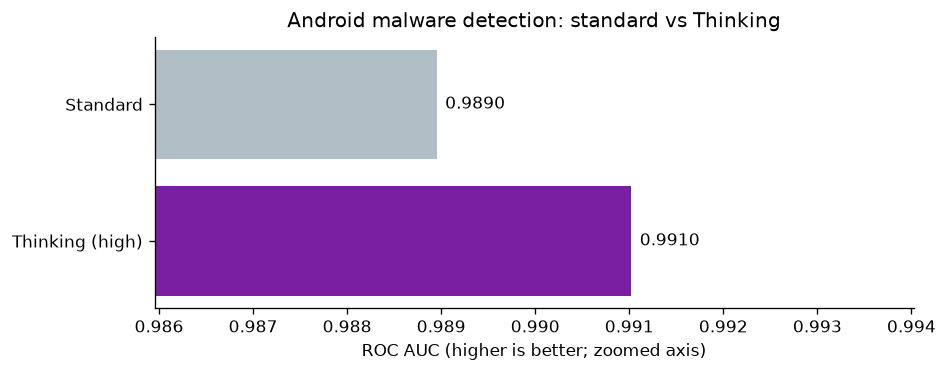

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.2))
scores = nat_results["ROC AUC"]
bars = ax.barh(scores.index, scores, color=["#b0bec5", "#7B1FA2"])
padding = max((scores.max() - scores.min()) * 0.7, 0.003)
ax.set_xlim(max(0, scores.min() - padding), min(1, scores.max() + padding))
ax.bar_label(bars, fmt="%.4f", padding=5)
ax.set(xlabel="ROC AUC (higher is better; zoomed axis)",
       title="Android malware detection: standard vs Thinking")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

![NATICUSdroid results](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/experiment_with_thinking_mode/naticus-results.png)

Thinking changes ROC AUC from **0.9890 to 0.9910** on this split.

## Mice proteins: use `group_col` for groups

The [UCI Mice Protein Expression dataset](https://doi.org/10.24432/C50S3Z)
contains 77 protein measurements and eight experimental classes, with
**15 observations per mouse across 72 mice**.

We use the [BeyondArena](https://huggingface.co/datasets/TabArena/BeyondArena)
version, which removes target-defining columns and provides animal identifiers
and grouped splits. This is a selected example of grouped data.
Credit: Higuera, Gardiner, and Cios (2015), CC BY 4.0.

In [9]:
def download_mice_file(filename):
    return hf_hub_download(
        "TabArena/BeyondArena",
        f"mice_protein_trisomy_discriminant/019d738d-99a8-7850-b911-f244ac4ad485/{filename}",
        repo_type="dataset", revision="88059a3f02ec4abb6ec24bbe0d1c0b7eed31485d",
    )

mice = pd.read_parquet(download_mice_file("dataset.parquet"))
published_splits = json.loads(Path(download_mice_file(
    "experiment_metadata.predictive-ml-splits-mold-v1.json"
)).read_text())["splits"]
# All three folds of the first published grouped repetition; no split search.
mice_splits = [published_splits["0"][str(fold)] for fold in range(3)]
assert not {"Genotype", "Treatment", "Behavior"} & set(mice.columns)
print(f"{len(mice):,} measurements, {mice.MouseID.nunique()} mice, {mice['class'].nunique()} classes")

1,080 measurements, 72 mice, 8 classes


### Evaluate on unseen mice

Use the three folds of BeyondArena's first grouped repetition. Each fold holds
out entire mice, with no animal shared between training and test data.

In [10]:
split_rows = []
for fold, (train, test) in enumerate(mice_splits):
    train_mice = set(mice.iloc[train].MouseID)
    test_mice = set(mice.iloc[test].MouseID)
    assert not set(train) & set(test)
    assert train_mice.isdisjoint(test_mice)
    split_rows.append({"Fold": fold, "Train rows": len(train), "Test rows": len(test),
                       "Train mice": len(train_mice), "Test mice": len(test_mice),
                       "Shared mice": len(train_mice & test_mice)})
display(pd.DataFrame(split_rows).set_index("Fold"))

,Train rows,Test rows,Train mice,Test mice,Shared mice
Fold,,,,,
0,720,360,48,24,0
1,720,360,48,24,0
2,720,360,48,24,0


### Pass the group column

For grouped data, use Thinking with `group_col="MouseID"` and keep that column
in both training and prediction DataFrames. Compare against standard TabPFN
using the protein features alone. Both use the same held-out mice;
`thinking_metric="log_loss"` selects our metric (lower is better).

In [11]:
mice_rows = []
for fold, (train, test) in enumerate(mice_splits):
    X_train = mice.iloc[train].drop(columns="class").copy()
    X_test = mice.iloc[test].drop(columns="class").copy()
    encoder = LabelEncoder().fit(mice.iloc[train]["class"])
    y_train = encoder.transform(mice.iloc[train]["class"])
    y_test = encoder.transform(mice.iloc[test]["class"])

    models = [
        ("Standard", TabPFNClassifier.create_default_for_version(ModelVersion.V3_5)),
        ("Thinking + group_col", TabPFNClassifier.create_default_for_version(
            ModelVersion.V3_5, thinking_effort="high", thinking_metric="log_loss",
            group_col="MouseID")),
    ]
    for name, model in models:
        # Only grouped Thinking receives the original mouse identities.
        Xtr = X_train if model.group_col else X_train.drop(columns="MouseID")
        Xte = X_test if model.group_col else X_test.drop(columns="MouseID")
        result = evaluate(model, Xtr, Xte, y_train, y_test, "log_loss")
        mice_rows.append({"Fold": fold, "Model": name, **result})
        print(f"Fold {fold}, {name}: log-loss {result['Score']:.4f}")

mice_results = pd.DataFrame(mice_rows).rename(columns={"Score": "Log-loss"})
display(mice_results.pivot(index="Fold", columns="Model", values="Log-loss").round(4))

Fold 0, Standard: log-loss 0.7729


Fold 0, Thinking + group_col: log-loss 0.7636


Fold 1, Standard: log-loss 0.6991


Fold 1, Thinking + group_col: log-loss 0.6913


Fold 2, Standard: log-loss 0.7970


Fold 2, Thinking + group_col: log-loss 0.7469


Model,Standard,Thinking + group_col
Fold,,
0,0.7729,0.7636
1,0.6991,0.6913
2,0.7970,0.7469


### Results on unseen mice

Bars show mean log-loss across the three folds; dots show individual folds.

,Log-loss,Seconds
Model,,
Standard,0.7563,3.6083
Thinking + group_col,0.7339,11.4407


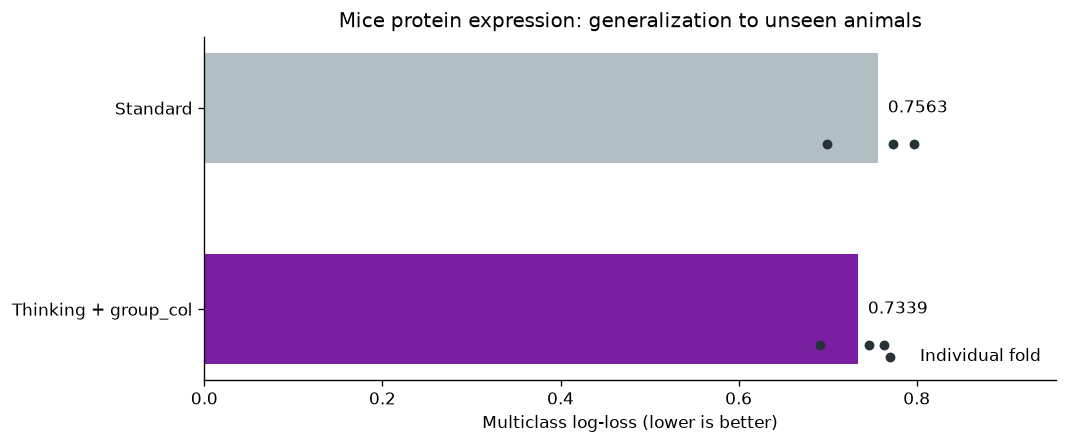

In [12]:
order = ["Standard", "Thinking + group_col"]
mice_summary = mice_results.groupby("Model")[["Log-loss", "Seconds"]].mean().reindex(order)
display(mice_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 3.8))
scores = mice_summary["Log-loss"]
bars = ax.barh(order, scores, color=["#b0bec5", "#7B1FA2"], height=0.55)
ax.bar_label(bars, fmt="%.4f", padding=6)
for position, name in enumerate(order):
    values = mice_results.loc[mice_results.Model == name, "Log-loss"]
    ax.scatter(values, np.full(len(values), position + 0.18), color="#263238", s=24,
               zorder=3, label="Individual fold" if position == 0 else None)
ax.set_xlim(0, mice_results["Log-loss"].max() * 1.2)
ax.set(xlabel="Multiclass log-loss (lower is better)",
       title="Mice protein expression: generalization to unseen animals")
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

![Mice protein results](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/experiment_with_thinking_mode/mice-results.png)

Thinking with `group_col="MouseID"` changes mean log-loss from **0.7563 to 0.7339** across the three folds, a **3.0% reduction**.

## Takeaways

- Set `thinking_metric` to match your task.
- For grouped data, use `group_col` and retain it at prediction time.
- Evaluate on held-out data; for repeated observations, hold out whole groups.